In [1]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Unavailable'}")

# Rutas
BASE_DIR  = "chest_xray"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val")

using: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
VALID_EXTENSIONS = (".jpeg",)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ChestXRayDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = {"NORMAL": 0, "PNEUMONIA": 1}
        
        for clase, idx in self.classes.items():
            folder = os.path.join(directory, clase)
            files = [f for f in os.listdir(folder) 
                       if f.lower().endswith(VALID_EXTENSIONS)]
            for file in files:
                self.images.append(os.path.join(folder, file))
                self.labels.append(idx)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transforms)
val_dataset   = ChestXRayDataset(VAL_DIR, transform=test_transforms)
test_dataset  = ChestXRayDataset(TEST_DIR, transform=test_transforms)

# Join train + val
train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

print(f"Train: {len(train_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Train: 5232 images
Test:  624 images


In [3]:
def calculate_weights(dataset):
    labels = []
    for d in dataset.datasets:
        labels.extend(d.labels)
    labels = np.array(labels)
    
    classes, counts = np.unique(labels, return_counts=True)
    class_weights = 1.0 / counts
    sample_weights = class_weights[labels]
    return torch.FloatTensor(sample_weights)

weights = calculate_weights(train_dataset)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 164
Test batches: 20


In [4]:
def build_model():
    # Load pre-trained DenseNet121 in ImageNet
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    
    # Freeze all layers so we don't modify the knowledge
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace original classifier (1000 classes) for ours (2 classes)
    num_features = model.classifier.in_features  # 1024 output features in DenseNet
    model.classifier = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)  # 2 classes: NORMAL y PNEUMONIA
    )
    
    return model.to(device)

model = build_model()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Total parameters:      {total:,}")
print(f"Trainable parameters:  {trainable:,}")
print(f"Frozen parameters:   {frozen:,}")

Total parameters:      7,216,770
Trainable parameters:  262,914
Frozen parameters:   6,953,856


In [5]:
def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr
    )
    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(epochs):
    
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()           # clean previous gradients
            outputs = model(images)         # forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()                 # backpropagation
            optimizer.step()               # update weights
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
        
        # Validation

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        history["train_loss"].append(train_loss / len(train_loader))
        history["train_acc"].append(train_correct / train_total)
        history["val_loss"].append(val_loss / len(test_loader))
        history["val_acc"].append(val_correct / val_total)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.4f}")
    
    return history

print("Phase 1 — Feature extraction")
history_phase1 = train_model(model, train_loader, test_loader, epochs=15, lr=1e-3)

Phase 1 — Feature extraction
Epoch 01/15 | Train Loss: 0.2828 | Train Acc: 0.8792 | Val Loss: 0.3198 | Val Acc: 0.8718
Epoch 02/15 | Train Loss: 0.2110 | Train Acc: 0.9167 | Val Loss: 0.4137 | Val Acc: 0.8301
Epoch 03/15 | Train Loss: 0.1922 | Train Acc: 0.9224 | Val Loss: 0.3226 | Val Acc: 0.8686
Epoch 04/15 | Train Loss: 0.1728 | Train Acc: 0.9371 | Val Loss: 0.3229 | Val Acc: 0.8686
Epoch 05/15 | Train Loss: 0.1803 | Train Acc: 0.9287 | Val Loss: 0.2917 | Val Acc: 0.8750
Epoch 06/15 | Train Loss: 0.1615 | Train Acc: 0.9407 | Val Loss: 0.3332 | Val Acc: 0.8830
Epoch 07/15 | Train Loss: 0.1604 | Train Acc: 0.9390 | Val Loss: 0.2919 | Val Acc: 0.8878
Epoch 08/15 | Train Loss: 0.1501 | Train Acc: 0.9404 | Val Loss: 0.3018 | Val Acc: 0.8734
Epoch 09/15 | Train Loss: 0.1634 | Train Acc: 0.9390 | Val Loss: 0.3238 | Val Acc: 0.8654
Epoch 10/15 | Train Loss: 0.1553 | Train Acc: 0.9385 | Val Loss: 0.3057 | Val Acc: 0.8782
Epoch 11/15 | Train Loss: 0.1668 | Train Acc: 0.9350 | Val Loss: 0.2860

In [6]:
def unfreeze_last_block(model):
    # Defrost the last dense block and final norm from DenseNet121

    for name, param in model.named_parameters():
        if "denseblock4" in name or "norm5" in name or "classifier" in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters after defrost: {trainable:,}")

unfreeze_last_block(model)

print("\nPhase 2 — Fine-tuning")
history_phase2 = train_model(model, train_loader, test_loader, epochs=10, lr=1e-5)

Trainable parameters after defrost: 2,423,042

Phase 2 — Fine-tuning
Epoch 01/10 | Train Loss: 0.1537 | Train Acc: 0.9404 | Val Loss: 0.3040 | Val Acc: 0.8830
Epoch 02/10 | Train Loss: 0.1072 | Train Acc: 0.9593 | Val Loss: 0.3009 | Val Acc: 0.8798
Epoch 03/10 | Train Loss: 0.1058 | Train Acc: 0.9581 | Val Loss: 0.3055 | Val Acc: 0.8830
Epoch 04/10 | Train Loss: 0.0986 | Train Acc: 0.9625 | Val Loss: 0.3127 | Val Acc: 0.8798
Epoch 05/10 | Train Loss: 0.0954 | Train Acc: 0.9666 | Val Loss: 0.2815 | Val Acc: 0.8846
Epoch 06/10 | Train Loss: 0.0954 | Train Acc: 0.9658 | Val Loss: 0.2892 | Val Acc: 0.8910
Epoch 07/10 | Train Loss: 0.0951 | Train Acc: 0.9652 | Val Loss: 0.3490 | Val Acc: 0.8814
Epoch 08/10 | Train Loss: 0.0820 | Train Acc: 0.9683 | Val Loss: 0.3072 | Val Acc: 0.8782
Epoch 09/10 | Train Loss: 0.0793 | Train Acc: 0.9706 | Val Loss: 0.3687 | Val Acc: 0.8798
Epoch 10/10 | Train Loss: 0.0739 | Train Acc: 0.9731 | Val Loss: 0.4116 | Val Acc: 0.8734


DenseNet121 Final Evaluation
              precision    recall  f1-score   support

      NORMAL       0.98      0.68      0.80       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.91      0.83      0.85       624
weighted avg       0.89      0.87      0.87       624



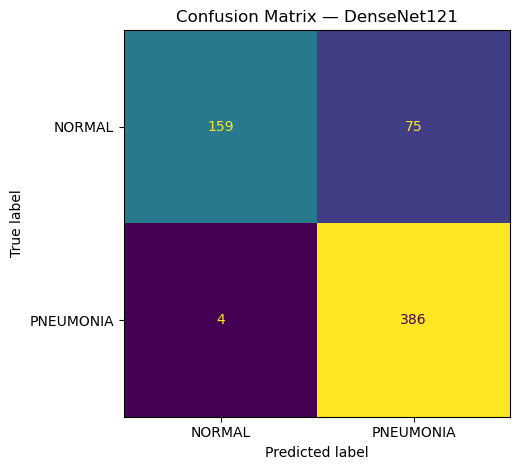

In [7]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("DenseNet121 Final Evaluation")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(colorbar=False)
plt.title("Confusion Matrix — DenseNet121")
plt.tight_layout()
plt.show()

In [8]:
torch.save(model.state_dict(), "densenet121_v1.pth")
print("v1 model saved - trained without offline augmentation")

v1 model saved - trained without offline augmentation


In [9]:
import random
from torchvision.transforms import functional as F

# Augmentation transformation to generate new images
augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

NORMAL_DIR = os.path.join(TRAIN_DIR, "NORMAL")
existing_images = [f for f in os.listdir(NORMAL_DIR) if f.lower().endswith(".jpeg")]

target = 3876  # for having balanced classes
needed = target - len(existing_images)
print(f"NORMAL actual images: {len(existing_images)}")
print(f"To be generated: {needed}")


generated = 0
while generated < needed:
   
    src_name = random.choice(existing_images)
    src_path = os.path.join(NORMAL_DIR, src_name)
    
    img = Image.open(src_path).convert("RGB")
    img_aug = augment(img)
    
    save_name = f"AUG_{generated:04d}_{src_name}"
    img_aug.save(os.path.join(NORMAL_DIR, save_name))
    generated += 1

print(f"\{generated} augmented images generated")
print(f"NORMAL total: {len(os.listdir(NORMAL_DIR)) - 1}")

NORMAL actual images: 1341
To be generated: 2535
\2535 augmented images generated
NORMAL total: 3876


In [10]:
model_v2 = build_model()
print("v2 model initialized from scratch")

v2 model initialized from scratch


In [11]:
train_dataset_v2 = ChestXRayDataset(TRAIN_DIR, transform=train_transforms)
val_dataset_v2   = ChestXRayDataset(VAL_DIR,   transform=test_transforms)
train_dataset_v2 = torch.utils.data.ConcatDataset([train_dataset_v2, val_dataset_v2])

print(f"Train v2: {len(train_dataset_v2)} images")
print(f"Test: {len(test_dataset)} images")

Train v2: 7767 images
Test: 624 images


In [12]:
weights_v2 = calculate_weights(train_dataset_v2)
sampler_v2 = WeightedRandomSampler(weights_v2, num_samples=len(weights_v2), replacement=True)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, sampler=sampler_v2, num_workers=0)

print(f"Train batches v2: {len(train_loader_v2)}")
print(f"Test batches: {len(test_loader)}")

Train batches v2: 243
Test batches: 20


In [13]:
print("v2 model - Phase 1: Feature extraction (backbone frozen)")
history_v2_phase1 = train_model(model_v2, train_loader_v2, test_loader, epochs=15, lr=1e-3)

v2 model - Phase 1: Feature extraction (backbone frozen)
Epoch 01/15 | Train Loss: 0.2429 | Train Acc: 0.8996 | Val Loss: 0.4447 | Val Acc: 0.8333
Epoch 02/15 | Train Loss: 0.1776 | Train Acc: 0.9282 | Val Loss: 0.6277 | Val Acc: 0.7804
Epoch 03/15 | Train Loss: 0.1747 | Train Acc: 0.9314 | Val Loss: 0.4614 | Val Acc: 0.8269
Epoch 04/15 | Train Loss: 0.1365 | Train Acc: 0.9475 | Val Loss: 0.4167 | Val Acc: 0.8381
Epoch 05/15 | Train Loss: 0.1499 | Train Acc: 0.9394 | Val Loss: 0.3660 | Val Acc: 0.8638
Epoch 06/15 | Train Loss: 0.1529 | Train Acc: 0.9392 | Val Loss: 0.3554 | Val Acc: 0.8654
Epoch 07/15 | Train Loss: 0.1323 | Train Acc: 0.9499 | Val Loss: 0.4325 | Val Acc: 0.8478
Epoch 08/15 | Train Loss: 0.1511 | Train Acc: 0.9413 | Val Loss: 0.5497 | Val Acc: 0.7949
Epoch 09/15 | Train Loss: 0.1251 | Train Acc: 0.9534 | Val Loss: 0.5530 | Val Acc: 0.8109
Epoch 10/15 | Train Loss: 0.1407 | Train Acc: 0.9445 | Val Loss: 0.6112 | Val Acc: 0.8029
Epoch 11/15 | Train Loss: 0.1347 | Train Ac

In [14]:
unfreeze_last_block(model_v2)

print("v2 model - Phase 2: Fine-tuning (denseblock4 unfrozen)")
history_v2_phase2 = train_model(model_v2, train_loader_v2, test_loader, epochs=10, lr=1e-5)

Trainable parameters after defrost: 2,423,042
v2 model - Phase 2: Fine-tuning (denseblock4 unfrozen)
Epoch 01/10 | Train Loss: 0.0933 | Train Acc: 0.9663 | Val Loss: 0.3943 | Val Acc: 0.8542
Epoch 02/10 | Train Loss: 0.0796 | Train Acc: 0.9696 | Val Loss: 0.4598 | Val Acc: 0.8413
Epoch 03/10 | Train Loss: 0.0782 | Train Acc: 0.9682 | Val Loss: 0.6021 | Val Acc: 0.8173
Epoch 04/10 | Train Loss: 0.0753 | Train Acc: 0.9714 | Val Loss: 0.4481 | Val Acc: 0.8478
Epoch 05/10 | Train Loss: 0.0670 | Train Acc: 0.9755 | Val Loss: 0.5404 | Val Acc: 0.8317
Epoch 06/10 | Train Loss: 0.0628 | Train Acc: 0.9772 | Val Loss: 0.6517 | Val Acc: 0.7997
Epoch 07/10 | Train Loss: 0.0548 | Train Acc: 0.9785 | Val Loss: 0.5645 | Val Acc: 0.8317
Epoch 08/10 | Train Loss: 0.0518 | Train Acc: 0.9795 | Val Loss: 0.5758 | Val Acc: 0.8253
Epoch 09/10 | Train Loss: 0.0507 | Train Acc: 0.9804 | Val Loss: 0.5116 | Val Acc: 0.8413
Epoch 10/10 | Train Loss: 0.0525 | Train Acc: 0.9811 | Val Loss: 0.5337 | Val Acc: 0.8333

--- DenseNet121 v2 Final Evaluation (with augmentation) ---
              precision    recall  f1-score   support

      NORMAL       0.95      0.59      0.73       234
   PNEUMONIA       0.80      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624



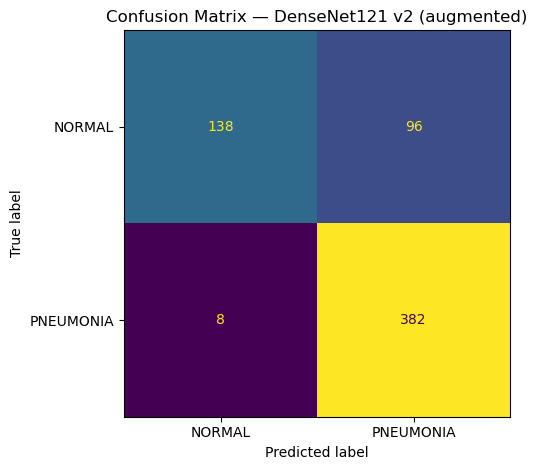

In [15]:
model_v2.eval()
all_preds_v2, all_labels_v2 = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v2(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_v2.extend(predicted.cpu().numpy())
        all_labels_v2.extend(labels.cpu().numpy())

all_preds_v2  = np.array(all_preds_v2)
all_labels_v2 = np.array(all_labels_v2)

print("--- DenseNet121 v2 Final Evaluation (with augmentation) ---")
print(classification_report(all_labels_v2, all_preds_v2, target_names=["NORMAL", "PNEUMONIA"]))

cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
disp_v2 = ConfusionMatrixDisplay(cm_v2, display_labels=["NORMAL", "PNEUMONIA"])
disp_v2.plot(colorbar=False)
plt.title("Confusion Matrix — DenseNet121 v2 (augmented)")
plt.tight_layout()
plt.show()

In [16]:
torch.save(model_v2.state_dict(), "densenet121_v2_augmented.pth")

In [17]:
"""
After trying to revert the bad recall the v1 model had, I tried to do an offline augmentation of the 
NORMAL class, so the dataset was balanced. This theoretically would improve learning but did exactly 
the opposite, the model learned the artificial transformations (result of the augmentation) instead 
of learning to generalize better. 
"""

'\nAfter trying to revert the bad recall the v1 model had, I tried to do an offline augmentation of the \nNORMAL class, so the dataset was balanced. This theoretically would improve learning but did exactly \nthe opposite, the model learned the artificial transformations (result of the augmentation) instead \nof learning to generalize better. \n'

In [18]:
# Load v1 model
model_gradcam = build_model()
model_gradcam.load_state_dict(torch.load("densenet121_v1.pth", map_location=device))
model_gradcam.eval()
print("Model loaded successfully")

Model loaded successfully


In [19]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# The target layer is the last convolutional block of DenseNet121
target_layer = [model_gradcam.features.denseblock4]

# Initialize GradCAM
cam = GradCAM(model=model_gradcam, target_layers=target_layer)

def visualize_gradcam(img_path, label_real, ax_img, ax_cam):
    # Load original image
    img_original = Image.open(img_path).convert("RGB")
    img_original = img_original.resize((224, 224))
    img_np = np.array(img_original, dtype=np.float32) / 255.0

    # Preprocess for model
    img_tensor = test_transforms(img_original).unsqueeze(0).to(device)

    # Calculate GradCAM
    targets = None  # None = use class with higher prob
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Overlay heatmap upon original image
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Obtain prediction
    with torch.no_grad():
        output = model_gradcam(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = "NORMAL" if pred_idx == 0 else "PNEUMONIA"
        confidence = probs[0][pred_idx].item()

    # Visualize
    ax_img.imshow(img_np)
    ax_img.set_title(f"Real: {label_real}", fontsize=10)
    ax_img.axis("off")

    ax_cam.imshow(visualization)
    ax_cam.set_title(f"Pred: {pred_label} ({confidence:.2f})", fontsize=10)
    ax_cam.axis("off")

print("GradCAM initialized")

GradCAM initialized


AttributeError: 'NoneType' object has no attribute 'shape'

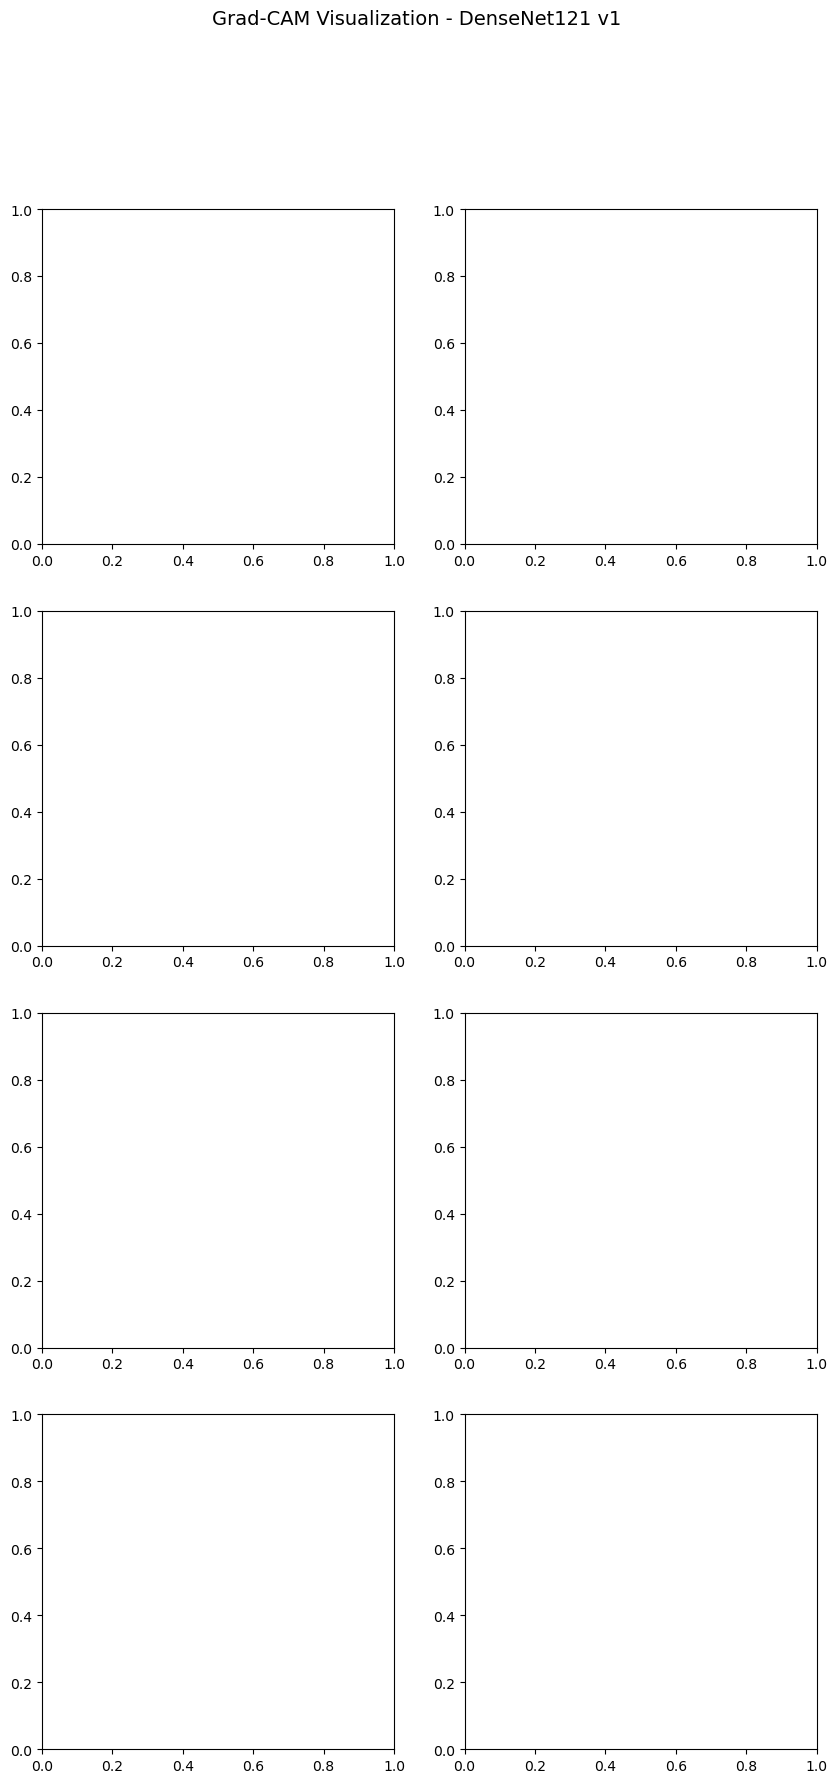

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle("Grad-CAM Visualization - DenseNet121 v1", fontsize=14)

# 2 NORMAL samples
normal_folder = os.path.join(TEST_DIR, "NORMAL")
normal_images = [f for f in os.listdir(normal_folder) if f.lower().endswith(".jpeg")][:2]

for i, img_name in enumerate(normal_images):
    img_path = os.path.join(normal_folder, img_name)
    visualize_gradcam(img_path, "NORMAL", axes[i][0], axes[i][1])

# 2 PNEUMONIA samples
pneumonia_folder = os.path.join(TEST_DIR, "PNEUMONIA")
pneumonia_images = [f for f in os.listdir(pneumonia_folder) if f.lower().endswith(".jpeg")][:2]

for i, img_name in enumerate(pneumonia_images):
    img_path = os.path.join(pneumonia_folder, img_name)
    visualize_gradcam(img_path, "PNEUMONIA", axes[i+2][0], axes[i+2][1])

plt.tight_layout()
plt.show()

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Gradients enabled in denseblock?
for name, param in model_gradcam.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True

target_layer = [model_gradcam.features.denseblock4.denselayer16.conv2]

# Restart GradCAM
cam = GradCAM(model=model_gradcam, target_layers=target_layer)

print("GradCAM restarted")

GradCAM restarted


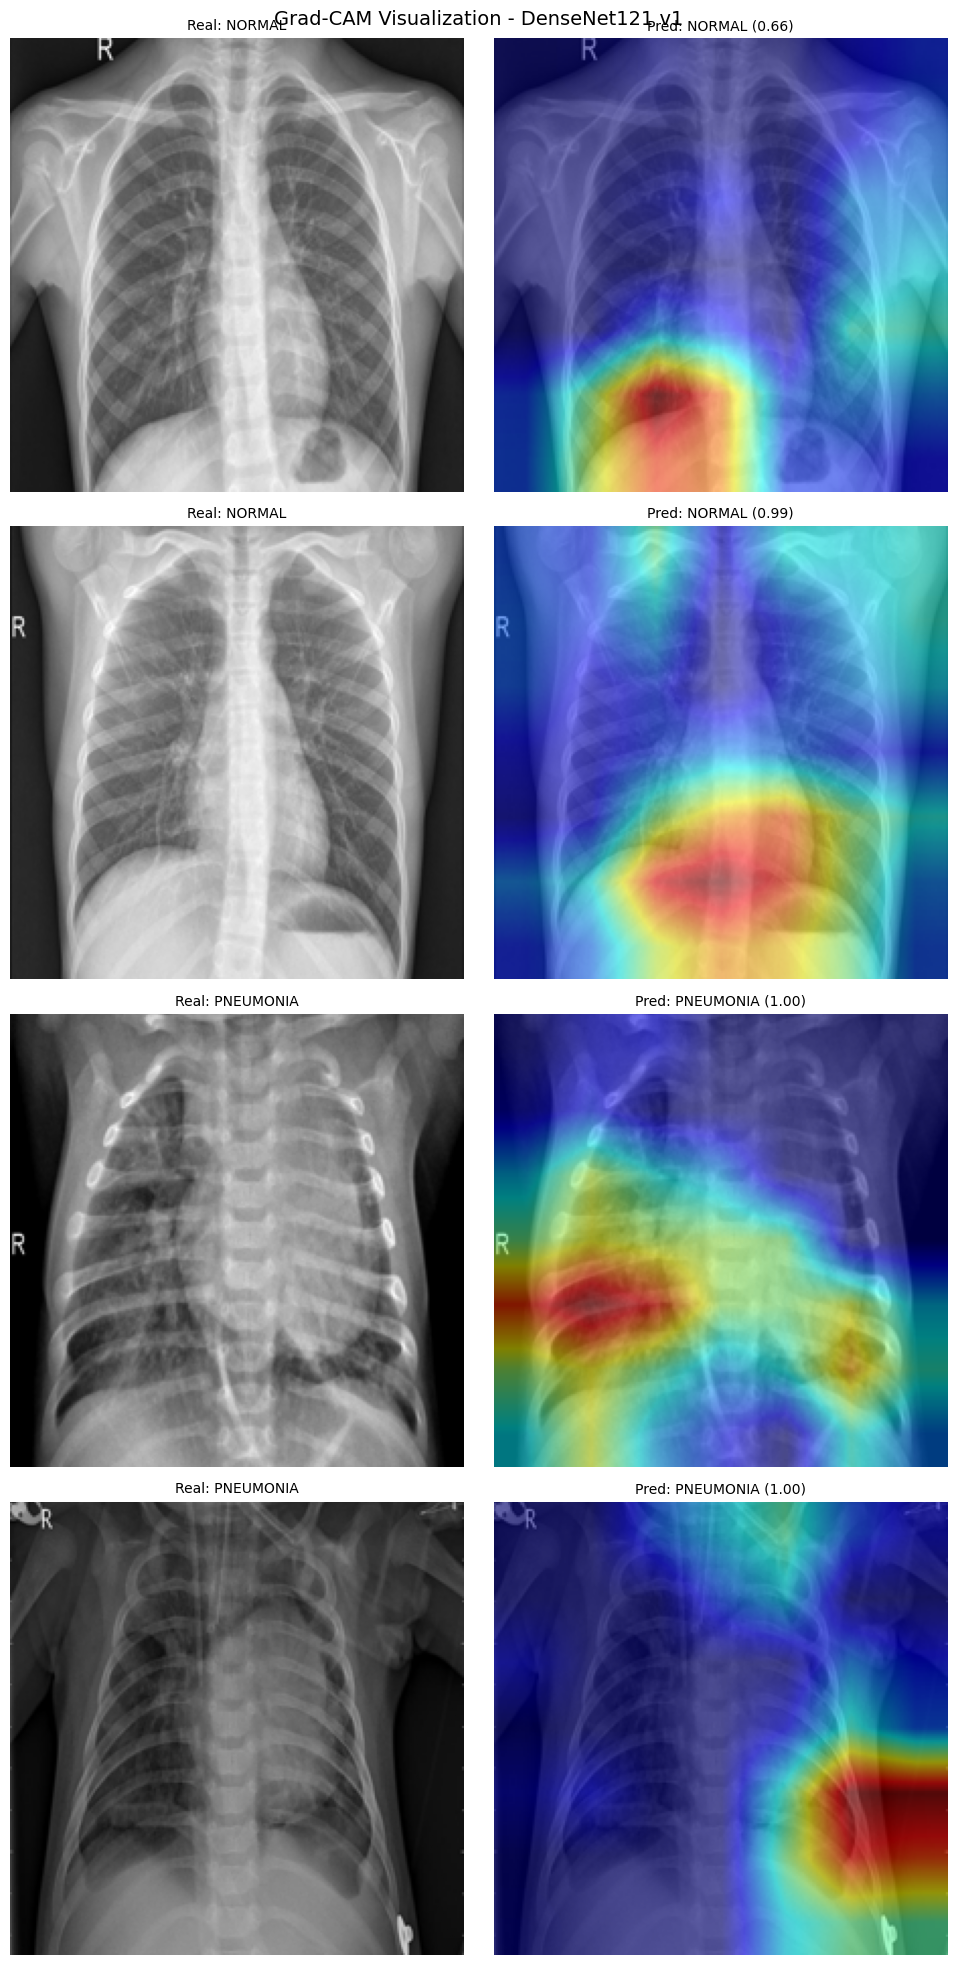

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle("Grad-CAM Visualization - DenseNet121 v1", fontsize=14)

# 2 NORMAL samples
normal_folder = os.path.join(TEST_DIR, "NORMAL")
normal_images = [f for f in os.listdir(normal_folder) if f.lower().endswith(".jpeg")][:2]

for i, img_name in enumerate(normal_images):
    img_path = os.path.join(normal_folder, img_name)
    visualize_gradcam(img_path, "NORMAL", axes[i][0], axes[i][1])

# 2 PNEUMONIA samples
pneumonia_folder = os.path.join(TEST_DIR, "PNEUMONIA")
pneumonia_images = [f for f in os.listdir(pneumonia_folder) if f.lower().endswith(".jpeg")][:2]

for i, img_name in enumerate(pneumonia_images):
    img_path = os.path.join(pneumonia_folder, img_name)
    visualize_gradcam(img_path, "PNEUMONIA", axes[i+2][0], axes[i+2][1])

plt.tight_layout()
plt.savefig(f"results/")
plt.show()

In [24]:
os.makedirs("gradcam_samples", exist_ok=True)

In [25]:
def save_gradcam(img_path, label_real, save_path):
    img_original = Image.open(img_path).convert("RGB")
    img_original = img_original.resize((224, 224))
    img_np = np.array(img_original, dtype=np.float32) / 255.0

    img_tensor = test_transforms(img_original).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model_gradcam(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = "NORMAL" if pred_idx == 0 else "PNEUMONIA"
        confidence = probs[0][pred_idx].item()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img_np)
    ax1.set_title(f"Real: {label_real}", fontsize=12)
    ax1.axis("off")
    ax2.imshow(visualization)
    ax2.set_title(f"Pred: {pred_label} ({confidence:.2f})", fontsize=12)
    ax2.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {save_path}")

# Save 3 normal and 3 pneumonia
normal_images = [f for f in os.listdir(os.path.join(TEST_DIR, "NORMAL")) 
                 if f.lower().endswith(".jpeg")][:3]
pneumonia_images = [f for f in os.listdir(os.path.join(TEST_DIR, "PNEUMONIA")) 
                    if f.lower().endswith(".jpeg")][:3]

for i, img_name in enumerate(normal_images):
    save_gradcam(
        os.path.join(TEST_DIR, "NORMAL", img_name),
        "NORMAL",
        f"gradcam_samples/normal_{i+1}.png"
    )

for i, img_name in enumerate(pneumonia_images):
    save_gradcam(
        os.path.join(TEST_DIR, "PNEUMONIA", img_name),
        "PNEUMONIA",
        f"gradcam_samples/pneumonia_{i+1}.png"
    )

print("\nSamples saved in gradcam_samples/")

Saved: gradcam_samples/normal_1.png
Saved: gradcam_samples/normal_2.png
Saved: gradcam_samples/normal_3.png
Saved: gradcam_samples/pneumonia_1.png
Saved: gradcam_samples/pneumonia_2.png
Saved: gradcam_samples/pneumonia_3.png

Samples saved in gradcam_samples/


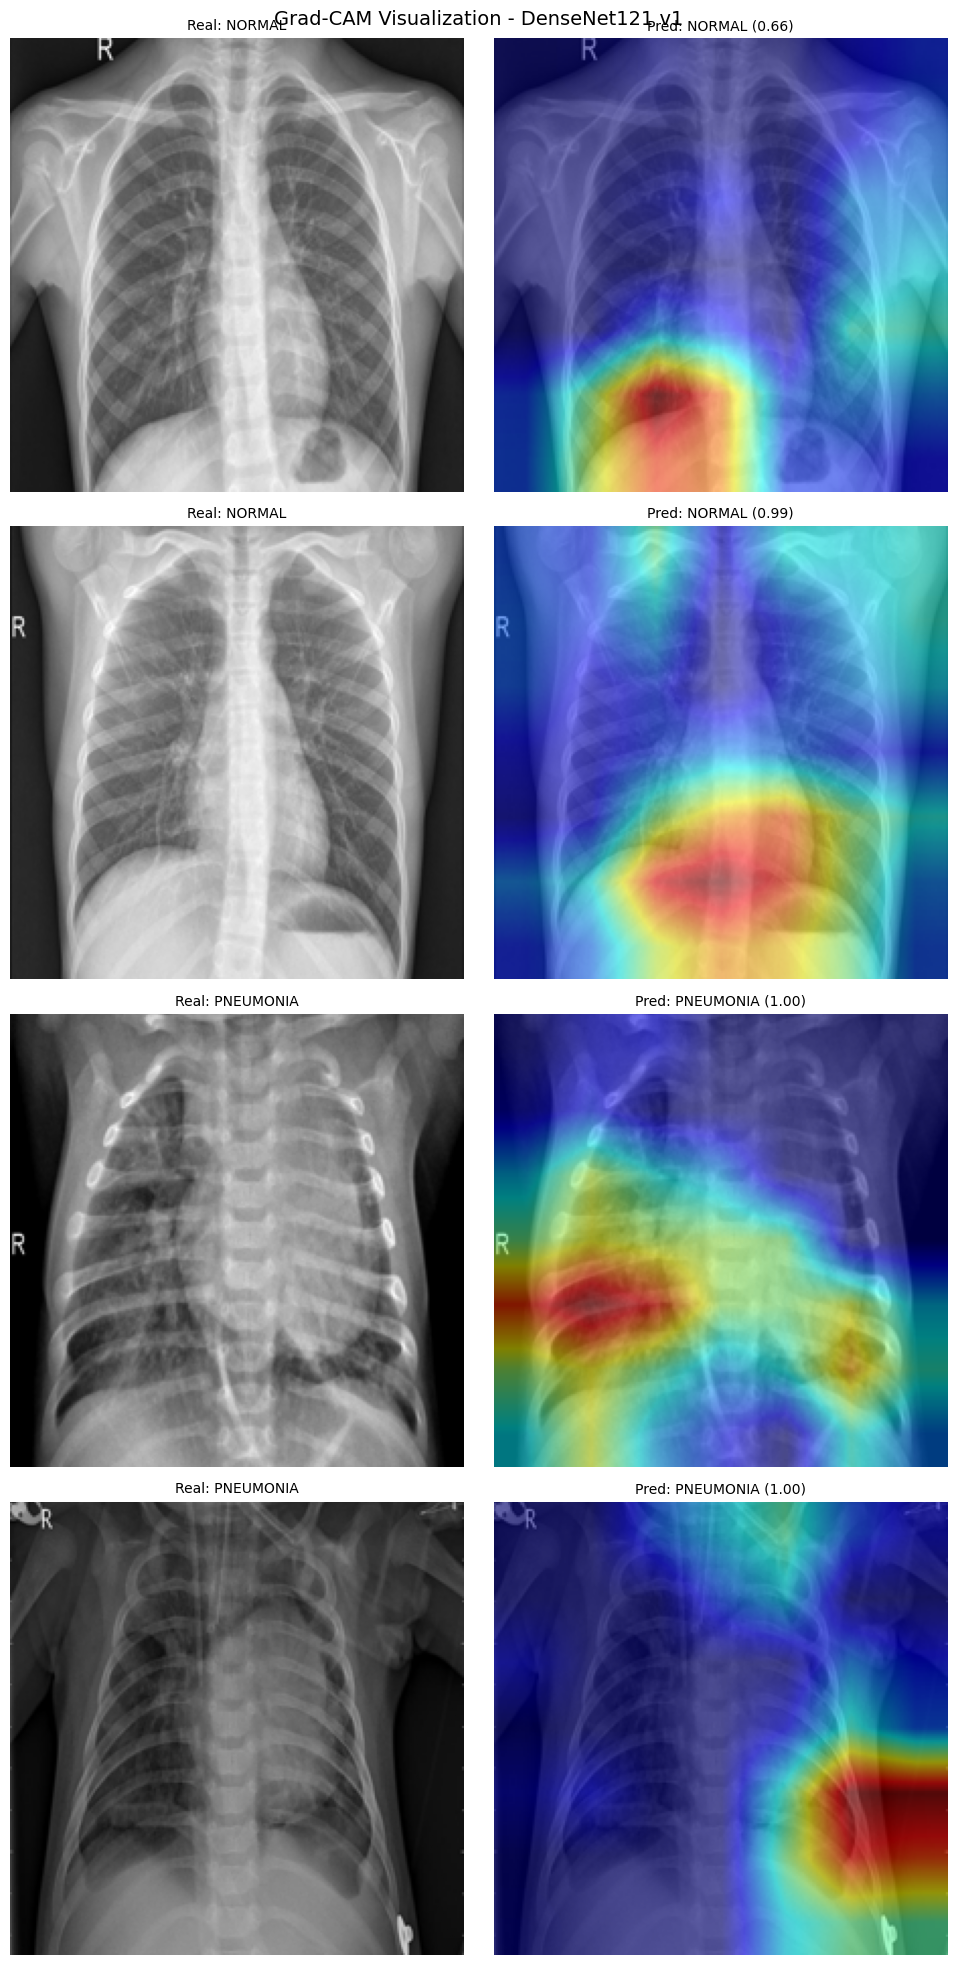

Overview saved


In [26]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle("Grad-CAM Visualization - DenseNet121 v1", fontsize=14)

casos = [
    (os.path.join(TEST_DIR, "NORMAL", normal_images[0]), "NORMAL"),
    (os.path.join(TEST_DIR, "NORMAL", normal_images[1]), "NORMAL"),
    (os.path.join(TEST_DIR, "PNEUMONIA", pneumonia_images[0]), "PNEUMONIA"),
    (os.path.join(TEST_DIR, "PNEUMONIA", pneumonia_images[1]), "PNEUMONIA"),
]

for i, (img_path, label) in enumerate(casos):
    visualize_gradcam(img_path, label, axes[i][0], axes[i][1])

plt.tight_layout()
plt.savefig("gradcam_samples/gradcam_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Overview saved")

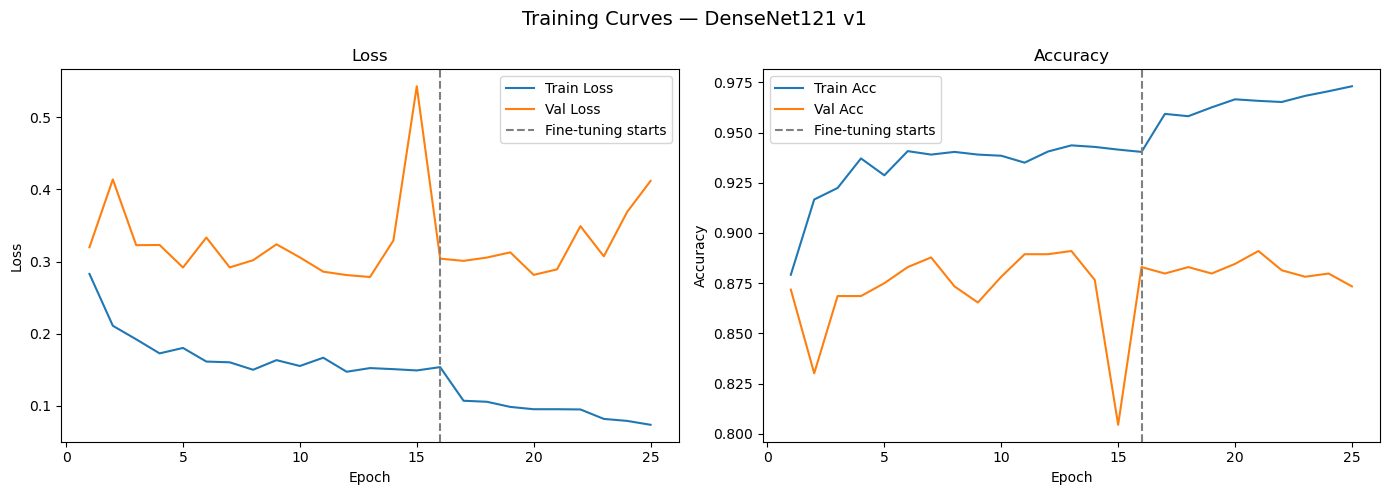

Curves saved


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves — DenseNet121 v1", fontsize=14)

# Combine phases
train_loss = history_phase1["train_loss"] + history_phase2["train_loss"]
val_loss   = history_phase1["val_loss"]   + history_phase2["val_loss"]
train_acc  = history_phase1["train_acc"]  + history_phase2["train_acc"]
val_acc    = history_phase1["val_acc"]    + history_phase2["val_acc"]

epochs_total = range(1, len(train_loss) + 1)
phase2_start = len(history_phase1["train_loss"]) + 1

# Loss
axes[0].plot(epochs_total, train_loss, label="Train Loss")
axes[0].plot(epochs_total, val_loss,   label="Val Loss")
axes[0].axvline(x=phase2_start, color="gray", linestyle="--", label="Fine-tuning starts")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(epochs_total, train_acc, label="Train Acc")
axes[1].plot(epochs_total, val_acc,   label="Val Acc")
axes[1].axvline(x=phase2_start, color="gray", linestyle="--", label="Fine-tuning starts")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_v1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curves saved")

In [28]:
import shutil

# Confusion matrix DenseNet121 v1
fig, ax = plt.subplots(figsize=(6, 5))
disp_v1 = ConfusionMatrixDisplay(
    confusion_matrix(all_labels, all_preds, labels=[0, 1]),
    display_labels=["NORMAL", "PNEUMONIA"]
)
disp_v1.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - DenseNet121 v1")
plt.tight_layout()
plt.savefig("results/dl_pipeline/confusion_matrix_v1.png", dpi=150, bbox_inches="tight")
plt.close()

# Confusion matrix DenseNet121 v2
fig, ax = plt.subplots(figsize=(6, 5))
disp_v2 = ConfusionMatrixDisplay(
    confusion_matrix(all_labels_v2, all_preds_v2, labels=[0, 1]),
    display_labels=["NORMAL", "PNEUMONIA"]
)
disp_v2.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - DenseNet121 v2 (augmented)")
plt.tight_layout()
plt.savefig("results/dl_pipeline/confusion_matrix_v2_augmented.png", dpi=150, bbox_inches="tight")
plt.close()

# Move previous copies to results/
shutil.copy("training_curves_v1.png", "results/dl_pipeline/training_curves_v1.png")
for f in os.listdir("gradcam_samples"):
    shutil.copy(f"gradcam_samples/{f}", f"results/dl_pipeline/gradcam/{f}")

print("All DL pipeline images saved in results/dl_pipeline/")

All DL pipeline images saved in results/dl_pipeline/
